In [ ]:
import sys
import os

# Compute absolute path to the src/ folder
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
src_path = os.path.join(project_root, "src")

# Add src/ to sys.path
sys.path.insert(0, src_path)

# Now you can import the code
from qvarnet.hamiltonians import GeneralHamiltonian, HarmonicOscillator
from qvarnet.models.mlp import MLP
from qvarnet.samplersv2 import MetropolisHastingsSampler
from qvarnet.utils.callback import EarlyStoppingCallback


import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.linalg import vector_norm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


- Local kinetic energy:

$$K_{loc} = -\frac12 \frac{\partial_x^2\psi}{\psi}$$

If $\partial_x \psi = \psi \partial_x\ln\psi$, then $\partial^2_x\psi = \partial_x(\psi\partial_x\ln\psi)\equiv \partial_x\psi\partial_x\ln\psi+\psi\partial_x^2\ln\psi$, and using again the first derivative identity:

$$\partial^2_x\psi =  \psi\bigg[(\partial_x\ln\psi)^2+\partial_x^2\ln\psi\bigg]$$

then:

$$K_{loc} = -\frac12\bigg[(\partial_x\ln\psi)^2+\partial_x^2\ln\psi\bigg]$$

In [3]:
class H_log_psi(nn.Module):
    def __init__(self, model):
        super(H_log_psi, self).__init__()
        self.model = model

    def local_kin_energy(self, x):
        log_psi = self.model(x)
        dlog_psi = torch.autograd.grad(log_psi, x, create_graph=True)[0]
        d2log_psi = torch.autograd.grad(dlog_psi, x, create_graph=True)[0]
        local_kinetic_energy = -0.5*(dlog_psi.pow(2) + d2log_psi)
        return local_kinetic_energy

    def local_potential_energy(self,x):
        # Assuming a harmonic oscillator potential V(x) = 0.5 * x^2
        local_potential_energy = 0.5 * x.pow(2)
        return local_potential_energy
    
    def forward(self, x):
        local_kinetic_energy = self.local_kin_energy(x)
        local_potential_energy = self.local_potential_energy(x)
        local_energy = local_kinetic_energy + local_potential_energy
        return local_energy

Gradients:

$$\nabla_\theta E = 2\bigg[\mathbb{E}_{x\sim\psi^2}E_L(x)\nabla_\theta \ln \psi\bigg]-\mathbb{E}_{x'\sim \psi^2}[E_L(x')]\mathbb{E}_{x\sim\psi^2}[\nabla_\theta\psi]$$

 10%|█         | 1/10 [00:01<00:11,  1.28s/it]

GRADIENTS MC:
Parameter model.0.weight:
 [[ 4.7304688 ]
 [-1.0028076 ]
 [ 3.4643555 ]
 [-0.6392822 ]
 [-0.10601807]
 [-6.2910156 ]
 [ 0.9387207 ]
 [-2.4685059 ]
 [-0.17718506]
 [-1.284668  ]]
Parameter model.0.bias:
 [-1.      0.25   -1.      0.      0.     -1.      0.      0.      0.0625
  0.    ]
Parameter model.2.weight:
 [[ 5.6103516e+00 -1.6937256e-03 -1.8188477e-01 -9.4067383e-01
   2.1882324e+00 -4.6069336e-01 -1.8896484e-01 -1.9008789e+00
   1.3726807e+00  1.5747070e+00]]
Parameter model.2.bias:
 [-33.]


 30%|███       | 3/10 [00:01<00:03,  2.14it/s]

100%|██████████| 10/10 [00:03<00:00,  3.01it/s]

Ended training.


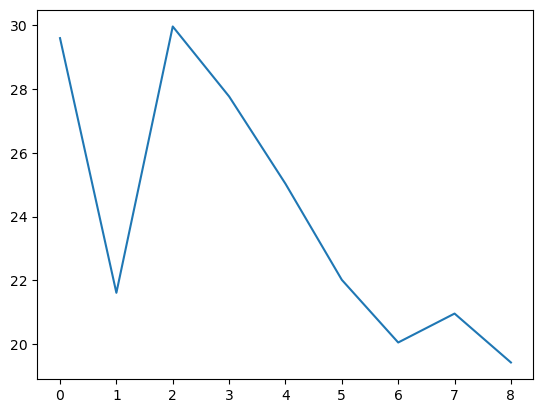

In [ ]:
import time
from tqdm import tqdm
import copy
from torchviz import make_dot


#----------------------- DEFINE PARAMETERS -----------------------
EPOCHS             = 1_0
N_SAMPLES          = 10_000
L_BOX              = 20.0
STEP_SIZE          = 0.1
BURN_IN            = 500
CALLBACK_PATIENCE  = 10000
CALLBACK_MIN_DELTA = 1e-5
LEARNING_RATE      = 1e-3
MLP_LAYER_DIMS     = [1, 10, 2]
DEBUG              = False

wf_history      = []
samples_history = []
energy_history  = []

local_energy_history = []
samples_history = []
dict_state_history = []

#----------------------- DEFINE MODEL TOPOLOGY -----------------------
model = MLP(layer_dims=MLP_LAYER_DIMS)
model.to(device)

# init weights

def init_weights(m):
    if isinstance(m, nn.Linear):
        # Small random weights - very important for VMC!
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(init_weights)

#------------------------ DEFINE HAMILTONIAN -----------------------
hamiltonian = H_log_psi(model)
hamiltonian.to(device)



#------------------------ DEFINE SAMPLER -----------------------
sampler = MetropolisHastingsSampler(
    model     = model,
    n_samples = N_SAMPLES,
    step_size = STEP_SIZE,
    burn_in   = BURN_IN,
    is_wf     = True,
    L_BOX     = L_BOX,
)
sampler.to(device)

# callback = EarlyStoppingCallback(patience=CALLBACK_PATIENCE, min_delta=CALLBACK_MIN_DELTA)
callback = None  # Disable early stopping for now

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

sampling_times = []
energy_times = []

x_trapezoid = torch.linspace(-L_BOX/2, L_BOX/2, 10_000).view(-1, 1).to(device)
x_trapezoid.requires_grad = True  # Ensure x_trapezoid is differentiable

for epoch in tqdm(range(EPOCHS)):
    optimizer.zero_grad()
    
    # x0 = torch.randn(1, device=device)
    start_sample_time = time.time()
    # Run sampler
    sampler.model = model
    x0 = torch.tensor([0.0], device=device)  # Initial point for the sampler
    samples = sampler(x0, method="parallel", n_walkers=(N_SAMPLES)).requires_grad_(False)
    # samples.requires_grad = True
    end_sample_time = time.time()
    sampling_times.append(end_sample_time - start_sample_time)
    samples_history.append(samples.cpu().detach())
    dict_state_history.append(model.state_dict())
    
    # Compute the mean and std of the local energy
    start_energy_time = time.time()
    hamiltonian.model = model
    local_energy = hamiltonian(samples)
    squared_psi = model(samples).pow(2)
    sampled_norm = torch.mean(squared_psi)
    local_energy_history.append(local_energy.cpu().detach())
    
    psi_values = model(samples)
    psi_std = psi_values.std()
    
    if psi_std < 1e-4:
        print(f"WARNING: Wavefunction becoming flat at epoch {epoch}! Restarting with new initialization...")
        model.apply(init_weights)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        continue
    
    end_energy_time = time.time()
    energy_times.append(end_energy_time - start_energy_time)
    
    # if EPOCHS == 1:
    #     plt.hist(samples.cpu().detach().numpy(), bins=100, density=True, alpha=0.7, label='Sampled')
    #     plt.plot(x_trapezoid.cpu().detach().numpy(), psi_trapezoid.cpu().detach().numpy()**2, label='Trapezoid Wavefunction')
    # elif epoch % 100 == 0:
    #     plt.hist(samples.cpu().detach().numpy(), bins=100, density=True, alpha=0.7, label='Sampled')
    #     plt.plot(x_trapezoid.cpu().detach().numpy(), psi_trapezoid.cpu().detach().numpy()**2, label='Trapezoid Wavefunction')
    #     plt.show()

    loss = local_energy.mean()
    energy_history.append(loss.item())
    
    # dot = make_dot(loss, params=dict(model.named_parameters()))
    # dot.render("loss_graph", format="png")  # Saves as loss_graph.png
    # dot.view()  # Opens the graph

    # print(f"ENERGY MEAN: {loss.item():.2f}±{local_energy.std().item():.2f}")
    
    wf_history.append(model.state_dict())
    samples_history.append(samples)

    
    # Compute gradients
    loss.squeeze().backward()
    
    # loss_trapzs.squeeze().backward()
    
    # # PRINT GRADIENTS
    if epoch % 100 == 0:
        print("GRADIENTS MC:")
        for name, param in model.named_parameters():
            if param is not None:
                print(f"Parameter {name}:\n {param.grad.data.cpu().numpy() if param.grad is not None else None}")

    # print("GRADIENTS TRAPEZOID:")
    # for name, param in model_for_trapz.named_parameters():
    #     if param is not None:
    #         print(f"Parameter {name}:\n {param.grad.data.cpu().numpy() if param.grad is not None else None}")
    # Update model parameters
    optimizer.step()
    # trapezoid_optimizer.step()
    
    sampler.reset_statistics()

print("Ended training.")
plt.plot(energy_history, label='Energy History')